# EXPLORACIÓN DEL SET DE DATOS

In [3]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# Configuración de estilos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Definir la ruta base
DATASET_PATH = Path(r"C:\Users\cjant\Downloads\Seed dataset\Seed dataset")

In [4]:
# 2. Escaneo del dataset y construcción de la tabla de metadatos
data = []

# Formatos de imagen a incluir
valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

print("Escaneando carpetas e imágenes...")

for category_dir in DATASET_PATH.iterdir():
    if category_dir.is_dir():
        scientific_name = category_dir.name
        
        for img_path in category_dir.iterdir():
            if img_path.suffix.lower() in valid_extensions:
                try:
                    # Abrir con PIL para obtener dimensiones sin cargar toda la imagen en RAM
                    with Image.open(img_path) as img:
                        width, height = img.size
                        mode = img.mode # RGB, L (Escala de grises), RGBA
                        format_type = img.format

                    # Tamaño del archivo en KB
                    file_size_kb = os.path.getsize(img_path) / 1024

                    data.append({
                        'category': scientific_name,
                        'file_path': str(img_path),
                        'filename': img_path.name,
                        'width': width,
                        'height': height,
                        'aspect_ratio': round(width / height, 2),
                        'channels': len(mode),
                        'mode': mode,
                        'format': format_type,
                        'size_kb': round(file_size_kb, 2)
                    })
                except Exception as e:
                    print(f"Error procesando {img_path}: {e}")

df_meta = pd.DataFrame(data)

print(f"\n¡Dataset cargado correctamente!")
print(f"Total de imágenes: {len(df_meta)}")
print(f"Total de clases/especies: {df_meta['category'].nunique()}\n")

# Mostrar una muestra de los metadatos extraídos
display(df_meta.head())

Escaneando carpetas e imágenes...

¡Dataset cargado correctamente!
Total de imágenes: 4496
Total de clases/especies: 88



,category,file_path,filename,width,height,aspect_ratio,channels,mode,format,size_kb
0,Achnatherum inebrians,C:\Users\cjant\Downloads\Seed dataset\Seed dat...,changed4002.jpg,192,272,0.71,3,RGB,JPEG,15.66
1,Achnatherum inebrians,C:\Users\cjant\Downloads\Seed dataset\Seed dat...,changed4003.jpg,192,272,0.71,3,RGB,JPEG,13.60
2,Achnatherum inebrians,C:\Users\cjant\Downloads\Seed dataset\Seed dat...,changed4004.jpg,192,272,0.71,3,RGB,JPEG,14.80
3,Achnatherum inebrians,C:\Users\cjant\Downloads\Seed dataset\Seed dat...,changed4005.jpg,192,272,0.71,3,RGB,JPEG,15.98
4,Achnatherum inebrians,C:\Users\cjant\Downloads\Seed dataset\Seed dat...,changed4006.jpg,192,272,0.71,3,RGB,JPEG,14.57


In [5]:
# 3. Resumen estadístico de resoluciones y tamaños
print("--- ESTADÍSTICAS DE DIMENSIONES Y TAMAÑO ---")
display(df_meta[['width', 'height', 'aspect_ratio', 'size_kb']].describe().T)


--- ESTADÍSTICAS DE DIMENSIONES Y TAMAÑO ---


,count,mean,std,min,25%,50%,75%,max
width,4496.0,192.000000,0.000000,192.00,192.0000,192.00,192.0000,192.00
height,4496.0,272.000000,0.000000,272.00,272.0000,272.00,272.0000,272.00
aspect_ratio,4496.0,0.710000,0.000000,0.71,0.7100,0.71,0.7100,0.71
size_kb,4496.0,15.121168,4.486546,5.39,11.6975,14.77,17.8325,33.58


C:\Users\cjant\AppData\Local\Temp\ipykernel_37992\10607992.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')


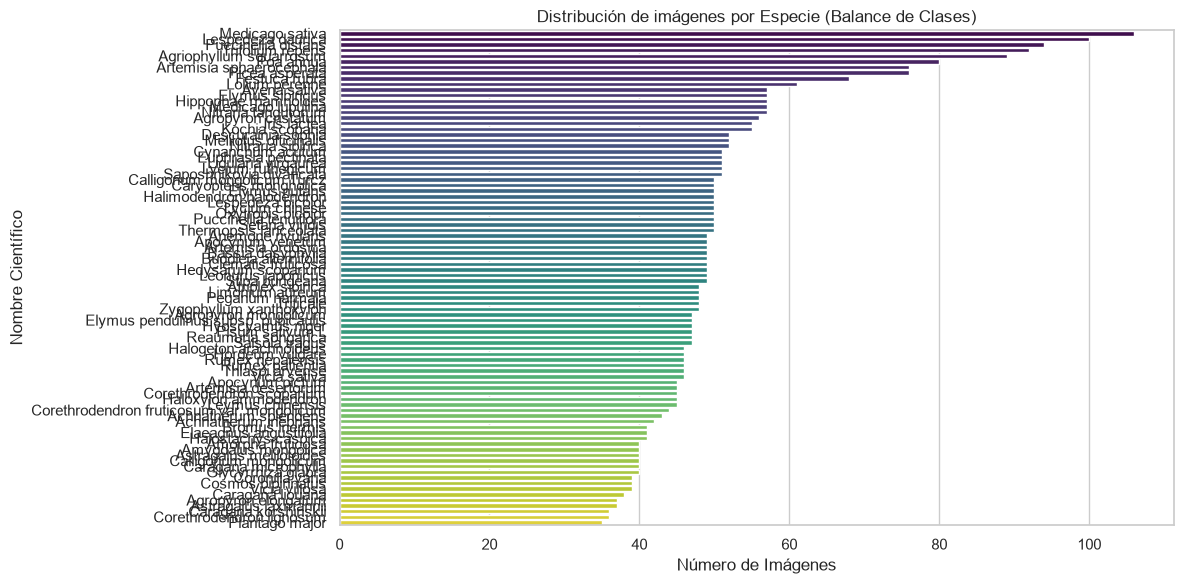

In [6]:
# 4. Distribución de imágenes por Clase / Nombre Científico
plt.figure(figsize=(12, 6))
class_counts = df_meta['category'].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')
plt.title('Distribución de imágenes por Especie (Balance de Clases)')
plt.xlabel('Número de Imágenes')
plt.ylabel('Nombre Científico')
plt.tight_layout()
plt.show()

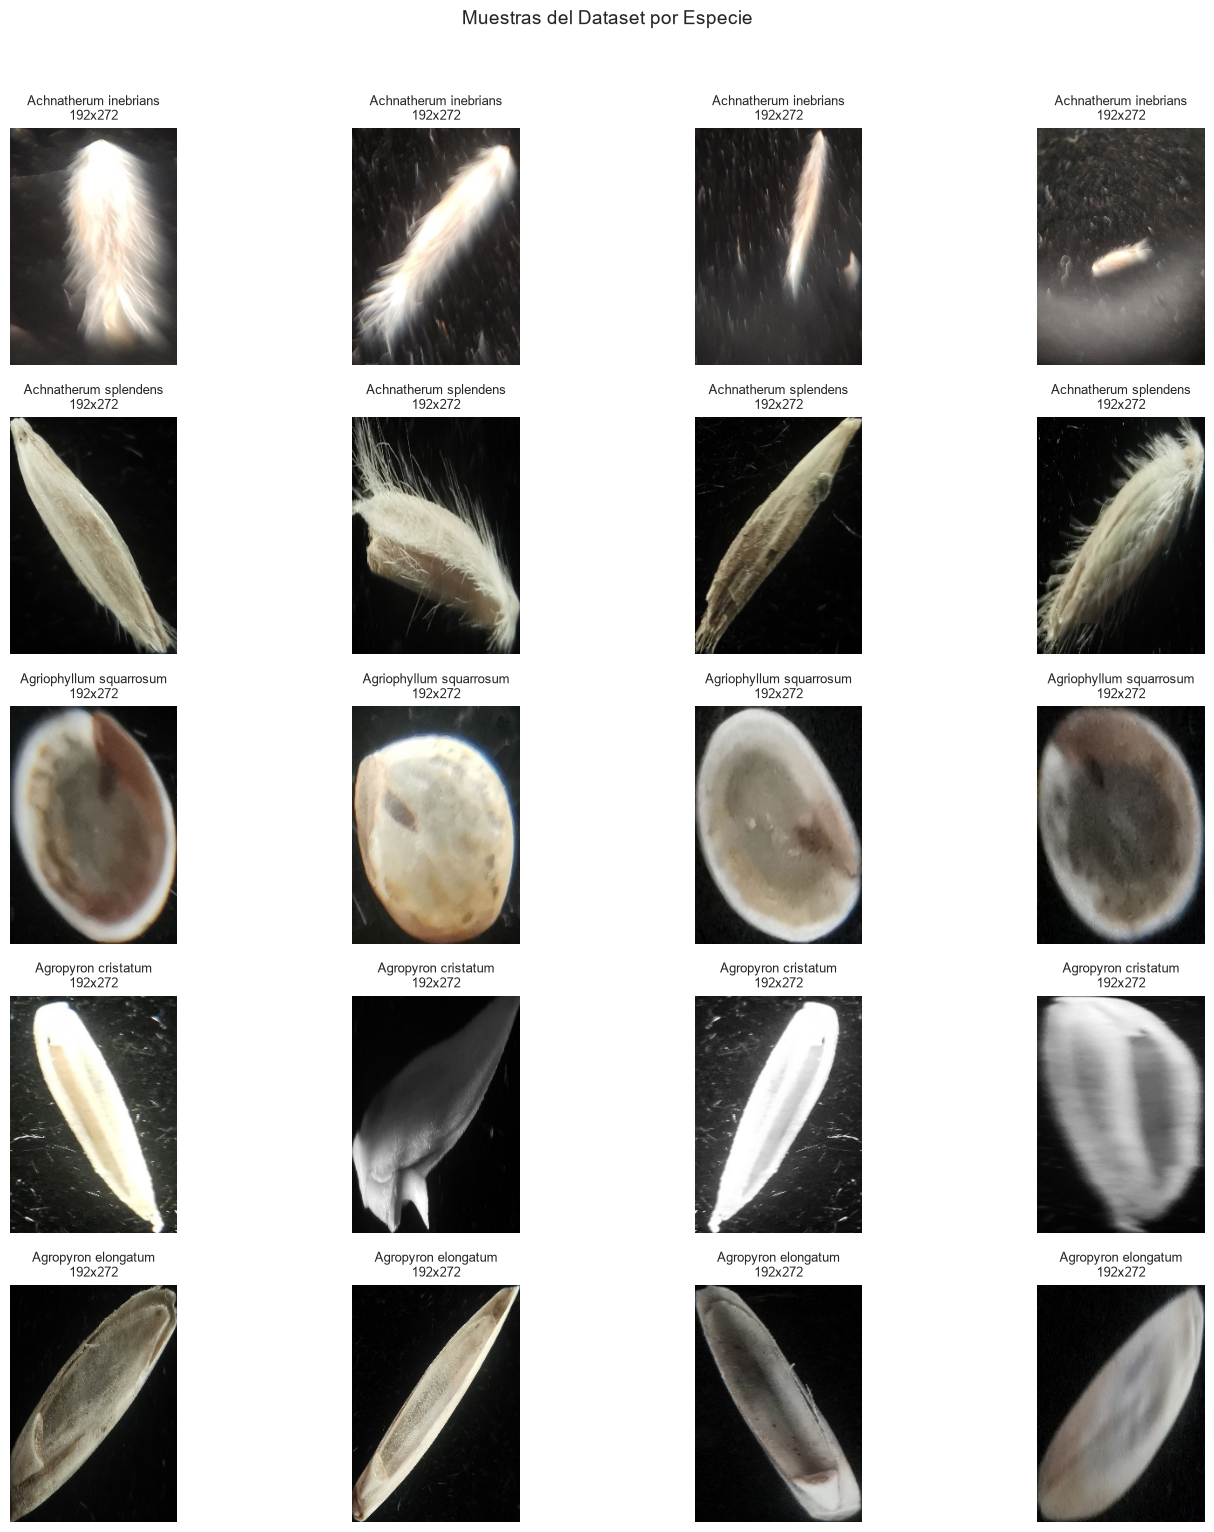

In [8]:
# 6. Visualización de Muestras de Imágenes (Grid por Especie)
categories = df_meta['category'].unique()
n_categories = len(categories)

# Mostramos hasta 5 categorías en caso de que sean muchas
display_cats = categories[:5] 
samples_per_cat = 4

fig, axes = plt.subplots(len(display_cats), samples_per_cat, figsize=(15, 3 * len(display_cats)))

for i, cat in enumerate(display_cats):
    cat_df = df_meta[df_meta['category'] == cat]
    sample_paths = cat_df.sample(min(samples_per_cat, len(cat_df)), random_state=42)['file_path'].values
    
    for j, path in enumerate(sample_paths):
        ax = axes[i, j] if len(display_cats) > 1 else axes[j]
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(f"{cat}\n{img.size[0]}x{img.size[1]}", fontsize=9)
        ax.axis('off')

plt.suptitle('Muestras del Dataset por Especie', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Calculando histogramas de color promedio en una muestra de imágenes...


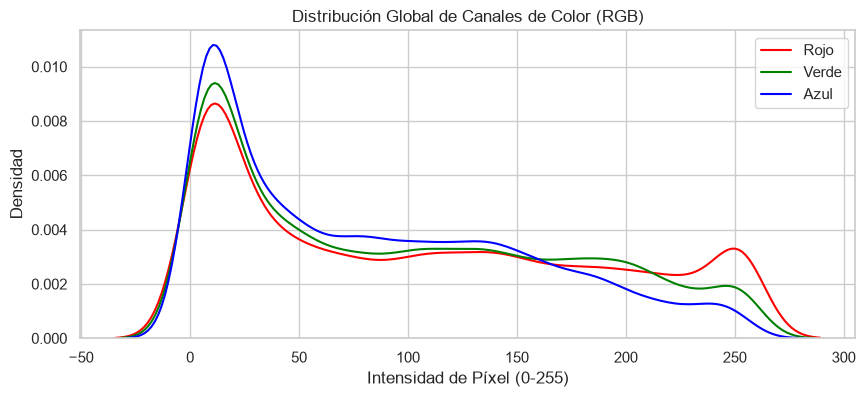

In [9]:
# 7. Distribución de Intensidad de Colores (Canales RGB)
print("Calculando histogramas de color promedio en una muestra de imágenes...")

sample_imgs = df_meta.sample(min(50, len(df_meta)), random_state=42)['file_path'].tolist()
r_vals, g_vals, b_vals = [], [], []

for p in sample_imgs:
    img = cv2.imread(p)
    if img is not None and len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        r_vals.extend(img_rgb[:, :, 0].flatten()[::100]) # Submuestreo para agilizar
        g_vals.extend(img_rgb[:, :, 1].flatten()[::100])
        b_vals.extend(img_rgb[:, :, 2].flatten()[::100])

plt.figure(figsize=(10, 4))
sns.kdeplot(r_vals, color='red', label='Rojo')
sns.kdeplot(g_vals, color='green', label='Verde')
sns.kdeplot(b_vals, color='blue', label='Azul')
plt.title('Distribución Global de Canales de Color (RGB)')
plt.xlabel('Intensidad de Píxel (0-255)')
plt.ylabel('Densidad')
plt.legend()
plt.show()